In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


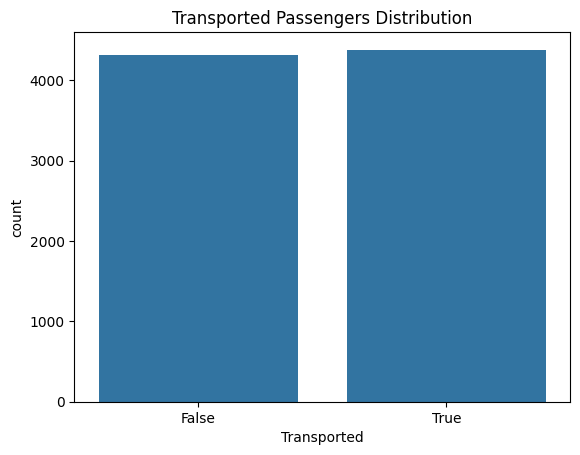

In [37]:
sns.countplot(x='Transported', data=train)
plt.title('Transported Passengers Distribution')
plt.show()

In [38]:
print("Missing values in train:")
print(train.isnull().sum())

Missing values in train:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


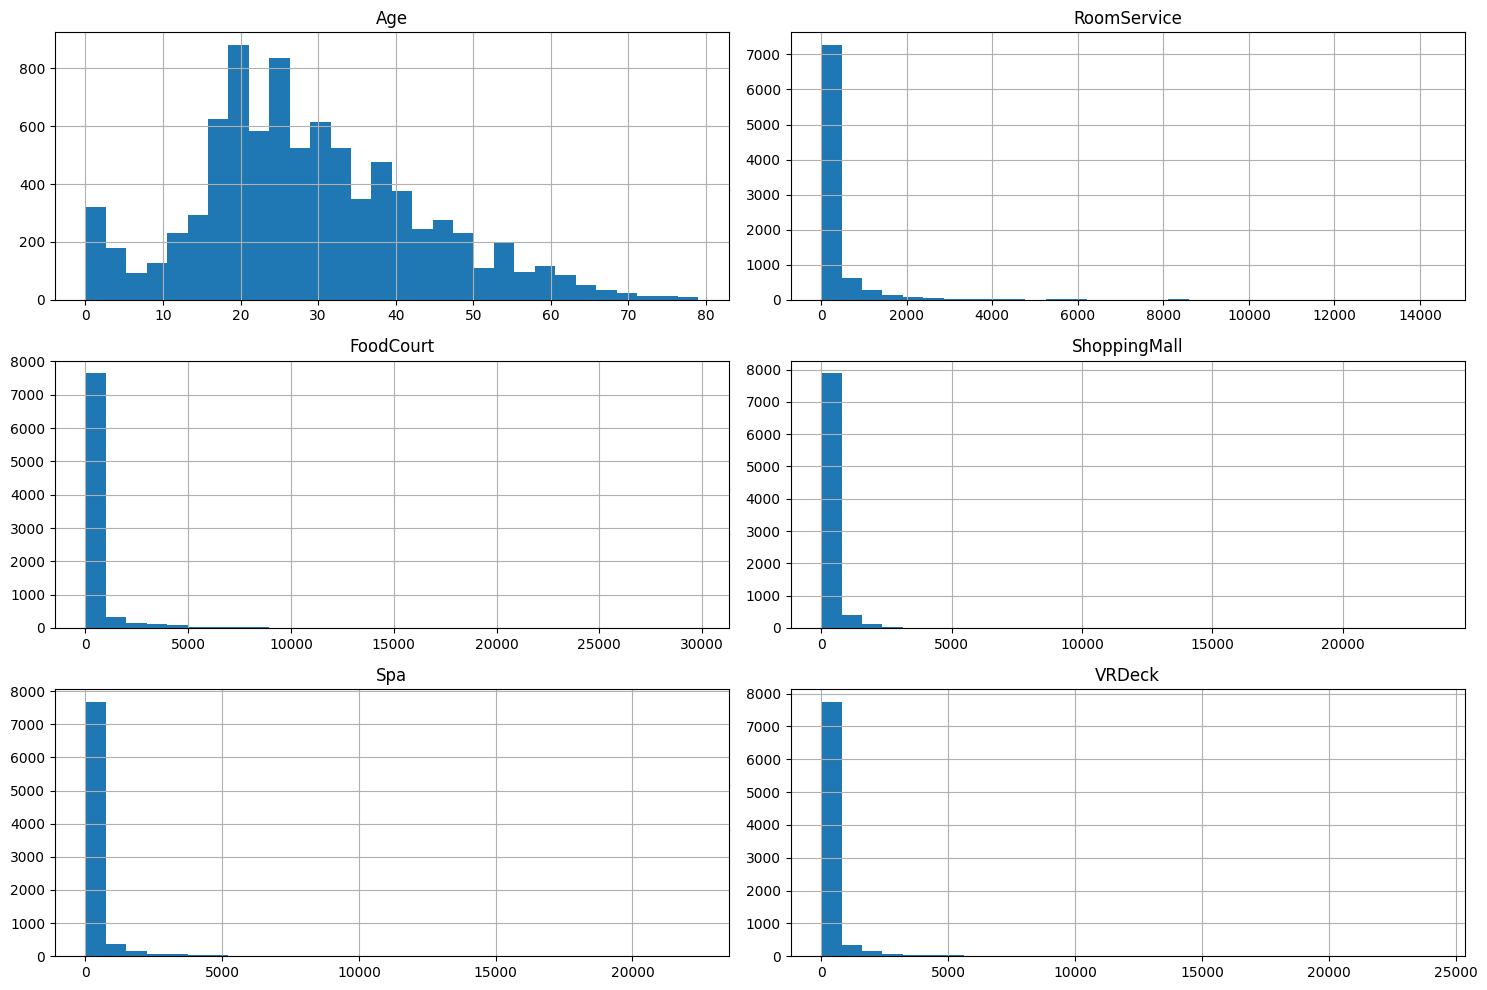

In [39]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [40]:
train['Group'] = train['PassengerId'].str.split('_').str[0]
test['Group'] = test['PassengerId'].str.split('_').str[0]

train['GroupSize'] = train.groupby('Group')['PassengerId'].transform('count')
test['GroupSize'] = test.groupby('Group')['PassengerId'].transform('count')

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train['TotalSpend'] = train[spend_cols].sum(axis=1)
test['TotalSpend'] = test[spend_cols].sum(axis=1)

train['Deck'] = train['Cabin'].str.split('/').str[0]
train['Side'] = train['Cabin'].str.split('/').str[2]
test['Deck'] = test['Cabin'].str.split('/').str[0]
test['Side'] = test['Cabin'].str.split('/').str[2]

drop_cols = ['PassengerId', 'Name', 'Cabin', 'Group']  
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [ ]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']


for col in spend_cols:
 train.loc[train['CryoSleep'] == True, col] = train.loc[train['CryoSleep'] == True, col].fillna(0)
 test.loc[test['CryoSleep'] == True, col] = test.loc[test['CryoSleep'] == True, col].fillna(0)
for col in num_cols:
 train[col] = train[col].fillna(train[col].median())
 test[col] = test[col].fillna(test[col].median())
for col in cat_cols:
 train[col] = train[col].fillna(train[col].mode()[0])
 test[col] = test[col].fillna(test[col].mode()[0])

In [43]:
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

missing_cols = set(train.columns) - set(test.columns)
for col in missing_cols:
 test[col] = 0

test = test[train.columns.drop('Transported')]

In [44]:
X = train.drop('Transported', axis=1)
y = train['Transported'].astype(int) 

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.7400805060379528

Confusion Matrix:
[[623 238]
 [214 664]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       861
           1       0.74      0.76      0.75       878

    accuracy                           0.74      1739
   macro avg       0.74      0.74      0.74      1739
weighted avg       0.74      0.74      0.74      1739



In [46]:
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_val, dt.predict(X_val))
    print(f"max_depth = {depth}, Accuracy = {acc:.4f}")

max_depth = 3, Accuracy = 0.7418
max_depth = 5, Accuracy = 0.7700
max_depth = 7, Accuracy = 0.7769
max_depth = 10, Accuracy = 0.7683
max_depth = 15, Accuracy = 0.7533
max_depth = None, Accuracy = 0.7401


In [47]:
best_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
best_dt.fit(X_train, y_train)  
final_acc = accuracy_score(y_val, best_dt.predict(X_val))
print("Final Model Accuracy:", final_acc)

Final Model Accuracy: 0.7768832662449684


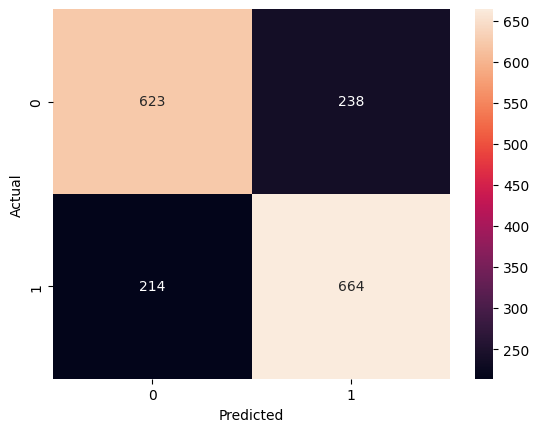

In [29]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

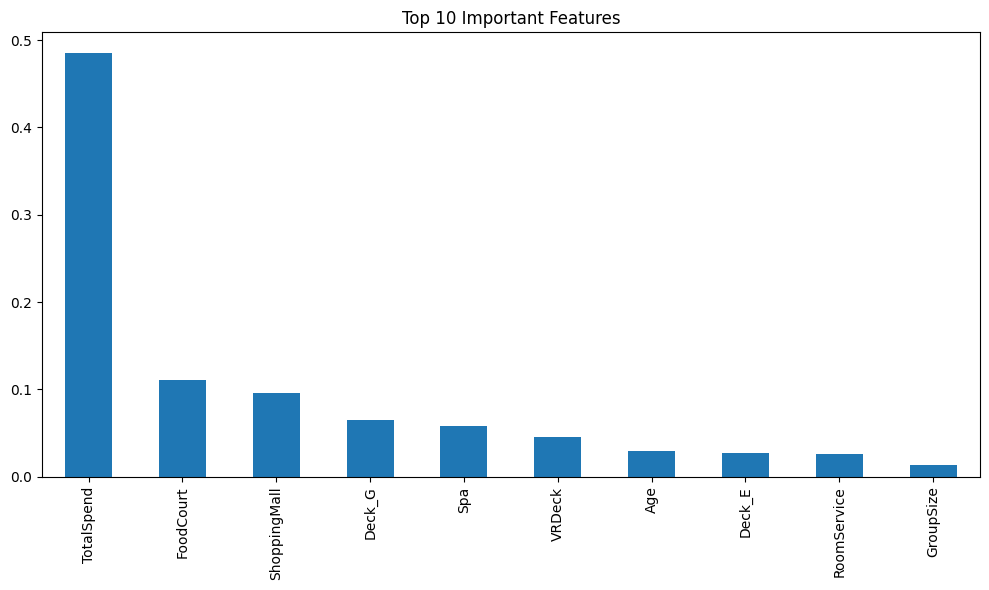

In [28]:
importances = best_dt.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
feat_imp.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

In [ ]:
test_predictions = best_dt.predict(test)
test_predictions_bool = test_predictions.astype(bool)
submission = pd.DataFrame({
 'PassengerId': pd.read_csv('test.csv')['PassengerId'],  
 'Transported': test_predictions_bool
})
submission.to_csv('submission.csv', index=False)
print("submission.csv file successfully created!")
print(submission.head())

submission.csv file successfully created!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
